# YBa$_2$Cu$_3$O$_6$ EFG point charge calculation

In [1]:
from pymatgen.core import Structure
import numpy as np
import pyEFGPointCharge
%matplotlib notebook
from isotopeDict import isotope_data_dict


## Load cif, prepare calc

In [10]:
# load a cif file and create a pymatgen.core.structure.Structure object with the info from said file.

#cif_file_name = 'SiO2_aCristobalite_EntryWithCollCode34927.cif'
cif_file_name = 'EntryWithCollCode75300.cif'
structure = Structure.from_file(cif_file_name)
print(structure)


Full Formula (Si4 O8)
Reduced Formula: SiO2
abc   :   4.971700   4.971700   6.922300
angles:  90.000000  90.000000  90.000000
Sites (12)
  #  SP          a        b       c
---  ----  -------  -------  ------
  0  Si4+  0.80028  0.19972  0.75
  1  Si4+  0.19972  0.80028  0.25
  2  Si4+  0.69972  0.69972  0.5
  3  Si4+  0.30028  0.30028  0
  4  O2-   0.7392   0.3956   0.5713
  5  O2-   0.2608   0.6044   0.0713
  6  O2-   0.8956   0.7608   0.3213
  7  O2-   0.1044   0.2392   0.8213
  8  O2-   0.6044   0.2608   0.9287
  9  O2-   0.3956   0.7392   0.4287
 10  O2-   0.7608   0.8956   0.6787
 11  O2-   0.2392   0.1044   0.1787


In [11]:
structure

Structure Summary
Lattice
    abc : 4.9717 4.9717 6.9223
 angles : 90.0 90.0 90.0
 volume : 171.104033100847
      A : 4.9717 0.0 3.044288245660448e-16
      B : 7.995103377397334e-16 4.9717 3.044288245660448e-16
      C : 0.0 0.0 6.9223
PeriodicSite: Si4+ (3.9788, 0.9929, 5.1917) [0.8003, 0.1997, 0.7500]
PeriodicSite: Si4+ (0.9929, 3.9788, 1.7306) [0.1997, 0.8003, 0.2500]
PeriodicSite: Si4+ (3.4788, 3.4788, 3.4612) [0.6997, 0.6997, 0.5000]
PeriodicSite: Si4+ (1.4929, 1.4929, 0.0000) [0.3003, 0.3003, 0.0000]
PeriodicSite: O2- (3.6751, 1.9668, 3.9547) [0.7392, 0.3956, 0.5713]
PeriodicSite: O2- (1.2966, 3.0049, 0.4936) [0.2608, 0.6044, 0.0713]
PeriodicSite: O2- (4.4527, 3.7825, 2.2241) [0.8956, 0.7608, 0.3213]
PeriodicSite: O2- (0.5190, 1.1892, 5.6853) [0.1044, 0.2392, 0.8213]
PeriodicSite: O2- (3.0049, 1.2966, 6.4287) [0.6044, 0.2608, 0.9287]
PeriodicSite: O2- (1.9668, 3.6751, 2.9676) [0.3956, 0.7392, 0.4287]
PeriodicSite: O2- (3.7825, 4.4527, 4.6982) [0.7608, 0.8956, 0.6787]
PeriodicSi

## Calculation

In [12]:
sphere_radius = 50


### Na

In [15]:
# instantiate the classes and define the relevant attributes therein.

# input_parameters is a class within the imported pyEFGPointCharge module
input_pars = pyEFGPointCharge.input_parameters()

##########################
# general input parameters
##########################
# path to cif file
input_pars.cif_file_name = cif_file_name

# create a supercell if one is required to define the magnetic structure
# the supercell_dimensions parameter should be a list of form [Na, Nb, Nc],
# where Na, Nb, and Nc are integers that represent the number of unit cells
# in the crystallographic a, b, and c directions, respectivly, contained in
# the supercell. For example, [1, 1, 2] will create a supercell that is 
# 1 x 1 x 2 unit cells in size. Note: creating a supercell modifies the
# lattice as well, therefore one must specify the magnetic_site_indices,
# probe indices, etc. in the supercell. see the following for details
# dipole_hyperfine_lattice_sum/ipynb_examples/LiCuVO4/
# LiCuVO4_dipole_hyperfine_calc_2021-08-30.ipynb
#input_pars.supercell_dimensions = [1, 1, 1]

# choose the radius around which we will include spins in angstroms with 
# respect to the probe position (float)
input_pars.sphere_radius = sphere_radius

# define the probe site number (nuclear spin site) (int)
input_pars.probe_site_index = 5

# for performing large calculations, we want to attempt to keep enough 
# memory. To do this we'll trash some arrays that we don't need
# running on 32bit python would cause memory allocation errors, so to 
# make the program more portable, we can allow for that memory to be 
# freed by the garbage collector by setting (no longer needed arrays 
# to None)
input_pars.delete_plotting_arrays = False

# probe nucleus identifying dictionary key (from isotope_data_dict) (string)
# e.g. '11B'
input_pars.probe_nucleus = "17O"

# or if you want to set a custom nuclear quadrupole moment, do that here and
# the default for the probe nucleus will be overridden
#input_pars.manual_nuclear_quad_moment = None

# in that case one also needs to define the nuclear spin I
#input_pars.manual_nuclear_spin = None

# define the charge sites by index in the cif file (list of ints)
# Note: that site indices in pymatgen start at zero.
# Further Note: if creating a supercell, one must include all magetic 
# site indices in the supercell. therefore the user must first know the 
# site indices.
input_pars.charge_site_indices = [i for i in range(len(structure))]

## adam, take a break üüüüüüüüüüwwüüüüüüüüüüüüü
# charges should be set to be a numpy array of shape = (len(charge_site_indices),), 
# the order of the charges should be the same as the charge_site_indices. units 
# are in multiples of the elementary charge e.
# Example:
# define antiferromagnetic order on the  magnetic sites with indices 0 and 1,
# so above charge_site_indices = [0, 1], and there is a charge of -2 on site 0
# and a +1 charge on site 1, then charges = np.array([-2.0, 1.0])
input_pars.first_cell_charges = [ 4,  4,  4,  4, 
                                 -2, -2, -2, -2, 
                                 -2, -2, -2, -2]

# Sternheimer antishielding factor (\gamma_\inf)
input_pars.gamma_sternheimer = -2.2

results = pyEFGPointCharge.results()
# a class for returning results of the calculation
# all results are in cartesian coordinates!!!
#class results:
    ## the structure object created from the cif file
    #structure = None
    ## a matrix representing the the lattice unit cell as row vectors in 
    ## cartesian coordinates (angstroms)
    #lattice = None
    ## Charge positions (angstroms)
    #charge_positions = None
    ## charges, in units of the elementary charge e
    #charges = None
    ## raw EFG tensor, ie not diagonalized (V m^-2)
    #V_ab_raw = None
    ## raw eigenvalues of the EFG tensor, ordered such that 
    ## |V_xx| <= |V_yy| <= |V_zz|; where x, y, and z no longer correspond to the 
    ## cartesian axes, but indicate the directions of the principal axes of the
    ## EFG tensor (V m^-2)
    #V_aa = None
    ## eigenvectors of the EFG tensor  (principal axes directions)
    ## (normalized, cartesian coordinates, a matrix of column vectors, 
    ## order is the same as the V_aa)
    #principal_axes = None
    ## eta = (V_xx - V_yy)/V_zz
    #eta = None
    ## nu_z = 3eQV_zz/(2I(2I-1)h)
    #nu_z_MHz = None
    ## nu_Q_MHz = nu_z_MHz(1 - eta**2/3)**0.5
    #nu_Q_MHz = None

###############################################################################

# run the calc
pyEFGPointCharge.calc_EFG_point_charge(input_pars, results)

# if we kept the vectors for plotting, then say how many spins we included in the calculation
if not input_pars.delete_plotting_arrays:
    N_charges = results.charge_positions.shape[0]
    print('calculated the EFG tensor via lattice sum for',
          '{:e}'.format(N_charges),
          'charges')
    

calculated the EFG tensor via lattice sum for 3.671000e+04 charges


In [16]:
# print the results (all in Cartesian coordinates)
print('structure =')
print(results.structure)
print('')
print('lattice (angstroms) =')
print(results.lattice)
print('')
print('probe_position (angstroms) =')
print(results.probe_position)
print('')
print('V_ab_raw (V m^-2) =')
print(results.V_ab_raw)
print('')
print('V_aa (V m^-2) =')
print(results.V_aa)
print('')
print('principal_axes (unitless) =')
print(results.principal_axes)
print('')
print('eta (unitless) =')
print(results.eta)
print('')
print('nu_z (MHz) =')
print(results.nu_z_MHz)
print('')
print('nu_Q (MHz) =')
print(results.nu_Q_MHz)
print('')


#print('charge_positions (angstroms) =')
#print(results.charge_positions)
#print('')
#print('charges (units of e) =')
#print(results.charges)
#print('')


structure =
Full Formula (Si4 O8)
Reduced Formula: SiO2
abc   :   4.971700   4.971700   6.922300
angles:  90.000000  90.000000  90.000000
Sites (12)
  #  SP          a        b       c    charge
---  ----  -------  -------  ------  --------
  0  Si4+  0.80028  0.19972  0.75           4
  1  Si4+  0.19972  0.80028  0.25           4
  2  Si4+  0.69972  0.69972  0.5            4
  3  Si4+  0.30028  0.30028  0              4
  4  O2-   0.7392   0.3956   0.5713        -2
  5  O2-   0.2608   0.6044   0.0713        -2
  6  O2-   0.8956   0.7608   0.3213        -2
  7  O2-   0.1044   0.2392   0.8213        -2
  8  O2-   0.6044   0.2608   0.9287        -2
  9  O2-   0.3956   0.7392   0.4287        -2
 10  O2-   0.7608   0.8956   0.6787        -2
 11  O2-   0.2392   0.1044   0.1787        -2

lattice (angstroms) =
[[4.97170000e+00 0.00000000e+00 0.00000000e+00]
 [7.99510338e-16 4.97170000e+00 0.00000000e+00]
 [4.23868627e-16 4.23868627e-16 6.92230000e+00]]

probe_position (angstroms) =
[1.296619

<IPython.core.display.Javascript object>


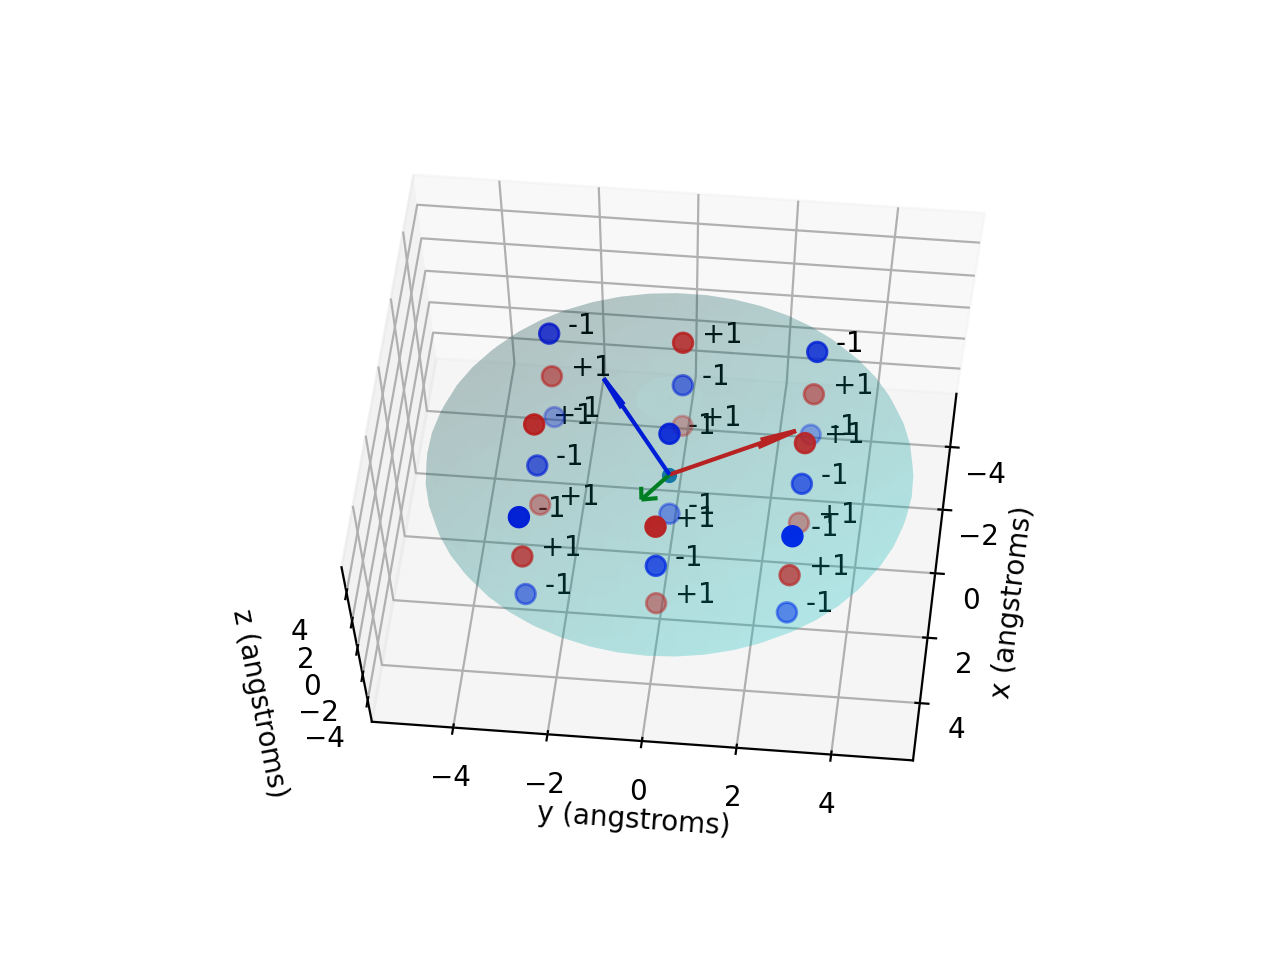

In [14]:
# display a visualization (note, should only do this for less than approx
# 50 atoms or it is not helpful

#%matplotlib notebook

# define the point-inclusion limits as a tuple
minmax=10
x_min_rel = -minmax
x_max_rel = minmax
y_min_rel = -minmax
y_max_rel = minmax
z_min_rel = -minmax
z_max_rel = minmax
pos_limits = (x_min_rel, x_max_rel, y_min_rel, y_max_rel, z_min_rel, z_max_rel)

# set the axes limits as a tuple
axes_min = -minmax
axes_max = minmax
ax_range = (axes_min, axes_max, axes_min, axes_max, axes_min, axes_max)

# uncommment to execute the visualization, also make sure delete_plotting_arrays = False
pyEFGPointCharge.visualization(input_parameters=input_pars,
                               results=results,
                               relative_position_limits=pos_limits,
                               axes_range=None,
                               elev=0.,
                               azim=0.,
                               plot_sphere=True,
                               plot_lattice_vectors=False)

## to do

verify code against other calculations
